# 带kv cache的Transformer

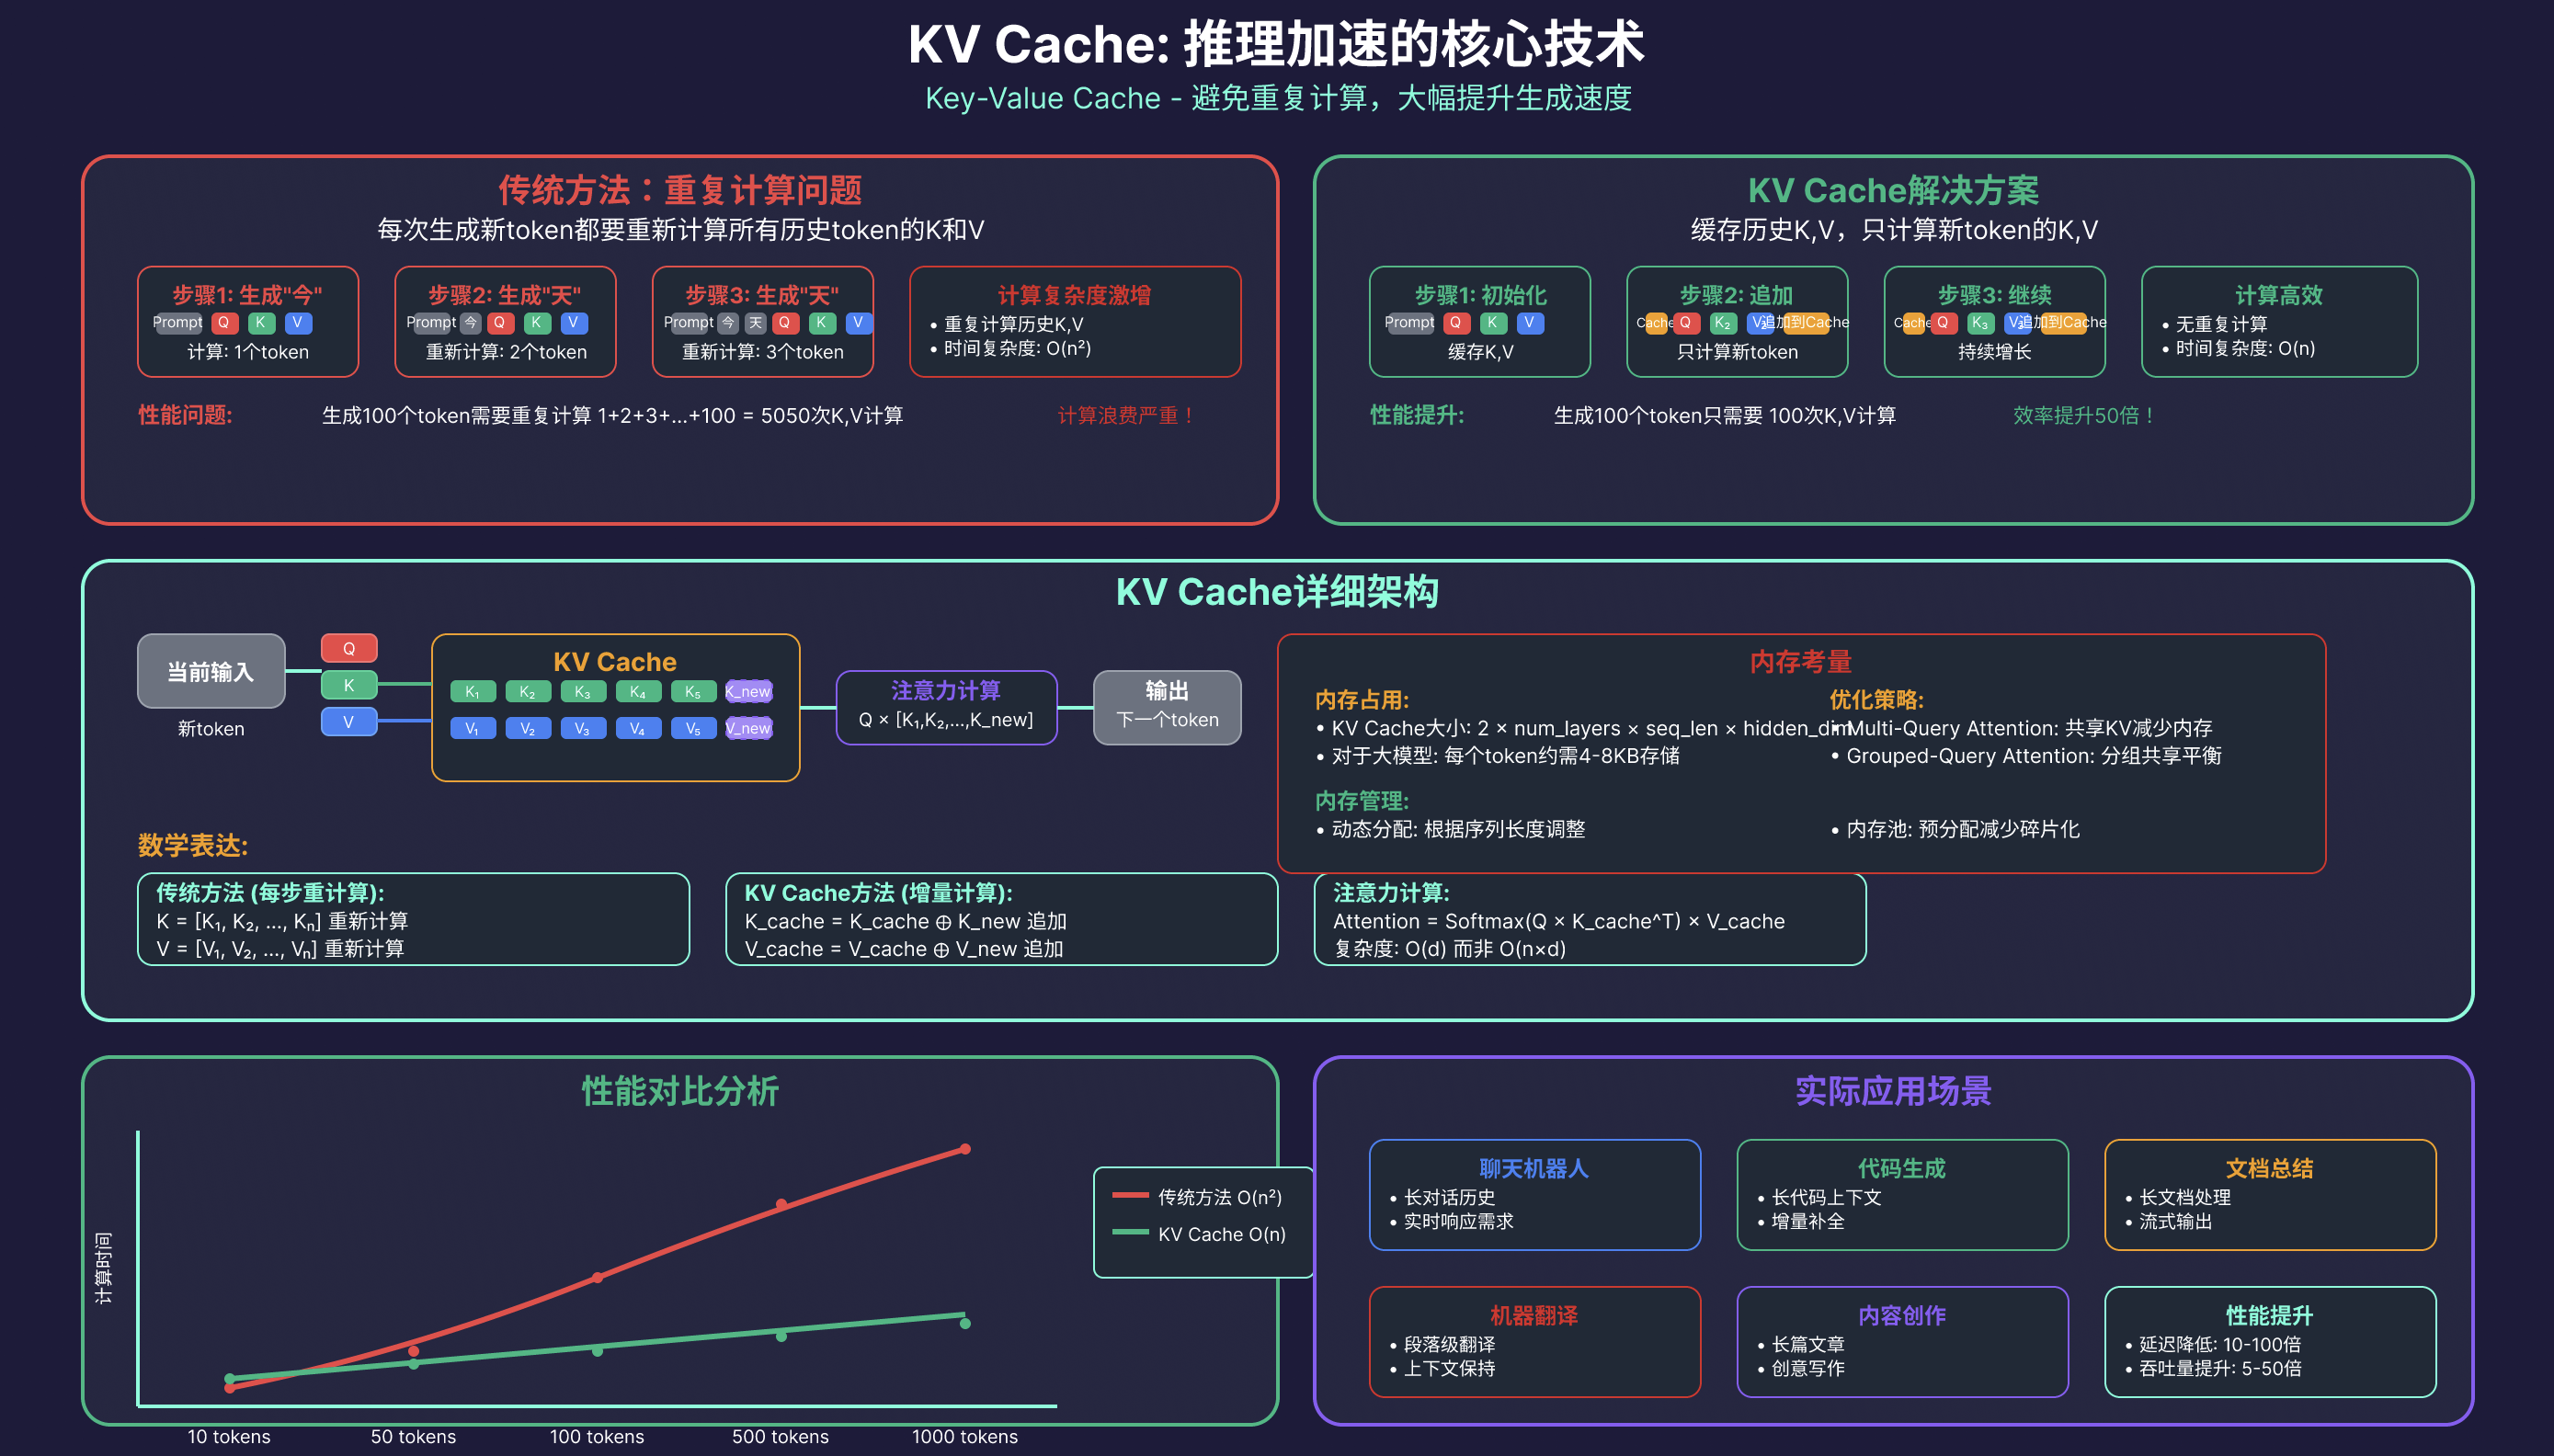

**课程为你提供两个版本的Transformer Decoder实现代码：一个带KV Cache优化，一个不带KV Cache，并进行性能对比。## 主要差异点：**

**1. KV Cache 机制：**
- 在`MultiHeadAttention`中，缓存每一层的Key和Value矩阵
- 新的推理步骤时，只需计算新token的K、V，然后与缓存的历史K、V拼接
- 避免了重复计算已处理过的token的attention

**2. 前向传播差异：**
- **带KV Cache**: 增量生成时只处理最后一个新token
- **不带KV Cache**: 每次都要处理完整序列

**3. 性能优化：**
- **时间复杂度**: 从O(n²)降低到O(n)
- **内存使用**: 用空间换时间，缓存历史计算结果

## 核心优势：

1. **计算效率**: 避免重复计算，特别是在长序列生成时效果显著
2. **实际加速**: 在实际应用中通常能获得2-10倍的推理速度提升
3. **可扩展性**: 序列越长，KV Cache的优势越明显


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        
    def forward(self, query, key, value, mask=None, kv_cache=None):
        batch_size, seq_len = query.shape[:2]
        
        # 计算Q, K, V
        Q = self.w_q(query)
        K = self.w_k(key)
        V = self.w_v(value)
        
        # Reshape for multi-head attention
        Q = Q.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        
        # 如果有KV cache，拼接历史的K和V
        if kv_cache is not None:
            if 'k' in kv_cache and 'v' in kv_cache:
                K = torch.cat([kv_cache['k'], K], dim=2)
                V = torch.cat([kv_cache['v'], V], dim=2)
            # 更新cache
            kv_cache['k'] = K
            kv_cache['v'] = V
        
        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        attention_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(attention_weights, V)
        
        # Concatenate heads
        context = context.transpose(1, 2).contiguous().view(
            batch_size, seq_len, self.d_model
        )
        
        output = self.w_o(context)
        return output

class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None, kv_cache=None):
        # Self-attention with residual connection
        attn_output = self.self_attn(x, x, x, mask, kv_cache)
        x = self.norm1(x + self.dropout(attn_output))
        
        # Feed-forward with residual connection
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        
        return x

class TransformerDecoderWithKVCache(nn.Module):
    """带KV Cache的Transformer Decoder"""
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_len=1000):
        super().__init__()
        self.d_model = d_model
        self.n_layers = n_layers
        
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Embedding(max_len, d_model)
        
        self.layers = nn.ModuleList([
            TransformerDecoderLayer(d_model, n_heads, d_ff)
            for _ in range(n_layers)
        ])
        
        self.layer_norm = nn.LayerNorm(d_model)
        self.output_proj = nn.Linear(d_model, vocab_size)
        
    def create_causal_mask(self, seq_len, device):
        """创建因果掩码"""
        mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
        return mask.unsqueeze(0).unsqueeze(0)  # [1, 1, seq_len, seq_len]
    
    def forward(self, input_ids, kv_caches=None):
        batch_size, seq_len = input_ids.shape
        device = input_ids.device
        
        # 如果是增量生成，只处理最后一个token
        if kv_caches is not None and len(kv_caches) > 0:
            # 增量生成模式：只处理新的token
            input_ids_new = input_ids[:, -1:]  # 只取最后一个token
            pos_ids = torch.arange(seq_len-1, seq_len, device=device).unsqueeze(0)
        else:
            # 完整序列处理
            input_ids_new = input_ids
            pos_ids = torch.arange(seq_len, device=device).unsqueeze(0)
            kv_caches = [{} for _ in range(self.n_layers)]
        
        # Embedding + Position encoding
        x = self.embedding(input_ids_new) + self.pos_encoding(pos_ids)
        
        # 创建掩码（对于完整的序列长度）
        if kv_caches is not None and len(kv_caches[0]) > 0:
            # 增量生成时的掩码处理
            full_seq_len = seq_len
            mask = torch.ones(1, 1, 1, full_seq_len, device=device)
        else:
            mask = self.create_causal_mask(seq_len, device)
        
        # 通过decoder layers
        for i, layer in enumerate(self.layers):
            x = layer(x, mask, kv_caches[i])
        
        x = self.layer_norm(x)
        logits = self.output_proj(x)
        
        return logits, kv_caches

class TransformerDecoderWithoutKVCache(nn.Module):
    """不带KV Cache的Transformer Decoder"""
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_len=1000):
        super().__init__()
        self.d_model = d_model
        
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Embedding(max_len, d_model)
        
        self.layers = nn.ModuleList([
            TransformerDecoderLayer(d_model, n_heads, d_ff)
            for _ in range(n_layers)
        ])
        
        self.layer_norm = nn.LayerNorm(d_model)
        self.output_proj = nn.Linear(d_model, vocab_size)
        
    def create_causal_mask(self, seq_len, device):
        mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
        return mask.unsqueeze(0).unsqueeze(0)
    
    def forward(self, input_ids):
        batch_size, seq_len = input_ids.shape
        device = input_ids.device
        
        # Position encoding
        pos_ids = torch.arange(seq_len, device=device).unsqueeze(0)
        
        # Embedding + Position encoding
        x = self.embedding(input_ids) + self.pos_encoding(pos_ids)
        
        # 创建因果掩码
        mask = self.create_causal_mask(seq_len, device)
        
        # 通过decoder layers
        for layer in self.layers:
            x = layer(x, mask)
        
        x = self.layer_norm(x)
        logits = self.output_proj(x)
        
        return logits

def generate_with_kv_cache(model, input_ids, max_new_tokens=20):
    """使用KV Cache进行文本生成"""
    model.eval()
    generated = input_ids.clone()
    kv_caches = None
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            # 前向传播
            logits, kv_caches = model(generated, kv_caches)
            
            # 取最后一个位置的logits进行预测
            next_token_logits = logits[:, -1, :]
            next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
            
            # 添加新token到序列中
            generated = torch.cat([generated, next_token], dim=1)
    
    return generated

def generate_without_kv_cache(model, input_ids, max_new_tokens=20):
    """不使用KV Cache进行文本生成"""
    model.eval()
    generated = input_ids.clone()
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            # 每次都要处理完整序列
            logits = model(generated)
            
            # 取最后一个位置的logits进行预测
            next_token_logits = logits[:, -1, :]
            next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
            
            # 添加新token到序列中
            generated = torch.cat([generated, next_token], dim=1)
    
    return generated

def benchmark_models():
    """性能基准测试"""
    # 模型参数
    vocab_size = 1000
    d_model = 512
    n_heads = 8
    n_layers = 6
    d_ff = 2048
    
    # 创建模型
    model_with_cache = TransformerDecoderWithKVCache(vocab_size, d_model, n_heads, n_layers, d_ff)
    model_without_cache = TransformerDecoderWithoutKVCache(vocab_size, d_model, n_heads, n_layers, d_ff)
    
    # 测试数据
    batch_size = 1
    initial_seq_len = 10
    max_new_tokens = 50
    
    input_ids = torch.randint(0, vocab_size, (batch_size, initial_seq_len))
    
    print("=== Transformer Decoder KV Cache 性能对比 ===")
    print(f"初始序列长度: {initial_seq_len}")
    print(f"生成新token数: {max_new_tokens}")
    print(f"模型参数: d_model={d_model}, n_heads={n_heads}, n_layers={n_layers}")
    print()
    
    # 测试带KV Cache的模型
    print("1. 测试带KV Cache的模型...")
    start_time = time.time()
    output_with_cache = generate_with_kv_cache(model_with_cache, input_ids, max_new_tokens)
    time_with_cache = time.time() - start_time
    
    print(f"   生成完成，耗时: {time_with_cache:.4f}秒")
    print(f"   最终序列长度: {output_with_cache.shape[1]}")
    print()
    
    # 测试不带KV Cache的模型
    print("2. 测试不带KV Cache的模型...")
    start_time = time.time()
    output_without_cache = generate_without_kv_cache(model_without_cache, input_ids, max_new_tokens)
    time_without_cache = time.time() - start_time
    
    print(f"   生成完成，耗时: {time_without_cache:.4f}秒")
    print(f"   最终序列长度: {output_without_cache.shape[1]}")
    print()
    
    # 性能对比
    speedup = time_without_cache / time_with_cache
    print("=== 性能对比结果 ===")
    print(f"不带KV Cache耗时: {time_without_cache:.4f}秒")
    print(f"带KV Cache耗时:   {time_with_cache:.4f}秒")
    print(f"加速比: {speedup:.2f}x")
    print(f"性能提升: {(speedup-1)*100:.1f}%")
    
    return time_with_cache, time_without_cache

if __name__ == "__main__":
    # 运行基准测试
    benchmark_models()
    
    print("\n=== KV Cache 原理说明 ===")
    print("1. 不带KV Cache: 每生成一个新token时，都要重新计算整个序列的attention")
    print("2. 带KV Cache: 缓存之前计算过的Key和Value，新token只需计算与历史的attention")
    print("3. 时间复杂度对比:")
    print("   - 不带KV Cache: O(n²) 每步都要处理完整序列")
    print("   - 带KV Cache: O(n) 每步只处理新token")
    print("4. 随着生成序列变长，KV Cache的优势会越来越明显")

=== Transformer Decoder KV Cache 性能对比 ===
初始序列长度: 10
生成新token数: 50
模型参数: d_model=512, n_heads=8, n_layers=6

1. 测试带KV Cache的模型...
   生成完成，耗时: 0.2461秒
   最终序列长度: 60

2. 测试不带KV Cache的模型...
   生成完成，耗时: 0.4460秒
   最终序列长度: 60

=== 性能对比结果 ===
不带KV Cache耗时: 0.4460秒
带KV Cache耗时:   0.2461秒
加速比: 1.81x
性能提升: 81.2%

=== KV Cache 原理说明 ===
1. 不带KV Cache: 每生成一个新token时，都要重新计算整个序列的attention
2. 带KV Cache: 缓存之前计算过的Key和Value，新token只需计算与历史的attention
3. 时间复杂度对比:
   - 不带KV Cache: O(n²) 每步都要处理完整序列
   - 带KV Cache: O(n) 每步只处理新token
4. 随着生成序列变长，KV Cache的优势会越来越明显
